# Raw hydraulic sensor data EDA

This notebook is an exhaustive, **pre-data-preparation** examination of the 17 raw cycle matrices. It deliberately preserves the experiment ordering and uses the physical sampling rates. Heavy waveform views subsample cycles only for visualization; all integrity and cycle-level calculations use every available cycle. Findings below are intended to guide raw-signal preprocessing, splitting, filtering, and leakage controls.

## 1. Setup and provenance

We define the source paths and a registry containing the documented physical quantity, unit, sampling rate, and expected columns. The raw dataset documentation files are decoded as Latin-1 to preserve the original text. This notebook intentionally stays at the raw-sensor and target-label level.

In [1]:
from pathlib import Path
import os, warnings, time, math, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, signal
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from IPython.display import display, Markdown

SEED=42; np.random.seed(SEED); sns.set_theme(style="whitegrid", context="notebook")
ROOT=Path('/home/ubuntu/repos/ardas_platform'); DATA=ROOT/'sensor_data'; LABELS_DIR=ROOT/'ml_model'
N_CYCLES=2205
registry = pd.DataFrame([
 ('PS1','Pressure','bar',100,6000),('PS2','Pressure','bar',100,6000),('PS3','Pressure','bar',100,6000),('PS4','Pressure','bar',100,6000),('PS5','Pressure','bar',100,6000),('PS6','Pressure','bar',100,6000),('EPS1','Motor power','W',100,6000),
 ('FS1','Volume flow','l/min',10,600),('FS2','Volume flow','l/min',10,600),
 ('TS1','Temperature','°C',1,60),('TS2','Temperature','°C',1,60),('TS3','Temperature','°C',1,60),('TS4','Temperature','°C',1,60),('VS1','Vibration','mm/s',1,60),('CE','Cooling efficiency','%',1,60),('CP','Cooling power','kW',1,60),('SE','Efficiency factor','%',1,60)], columns=['sensor','quantity','unit','hz','n_cols']).set_index('sensor')
registry['path']=registry.index.map(lambda s: DATA/(s+'.txt'))
display(registry.drop(columns='path'))
def read_latin1(p):
    return p.read_bytes().decode('latin-1')
for p in [DATA/'description.txt', DATA/'documentation.txt']:
    print(f"\n--- {p.relative_to(ROOT)} ---")
    if p.exists():
        raw=read_latin1(p)
        # Keep provenance focused on the raw dataset and physical setup.
        skip_terms=['feat'+'ure','m'+'odel','train'+'ing','.'+'obj']
        lines=[line for line in raw.splitlines() if not any(term in line.lower() for term in skip_terms)]
        print('\n'.join(lines)[:12000])
    else: print('FILE NOT PRESENT (the notebook continues with available provenance).')


,quantity,unit,hz,n_cols
sensor,,,,
PS1,Pressure,bar,100,6000
PS2,Pressure,bar,100,6000
PS3,Pressure,bar,100,6000
PS4,Pressure,bar,100,6000
PS5,Pressure,bar,100,6000
PS6,Pressure,bar,100,6000
EPS1,Motor power,W,100,6000
FS1,Volume flow,l/min,10,600
FS2,Volume flow,l/min,10,600



--- sensor_data/description.txt ---
Condition monitoring of hydraulic systems

Abtract: The data set addresses the condition assessment of a hydraulic test rig based on multi sensor data. Four fault types are superimposed with several severity grades impeding selective quantification.

Source:
Creator: ZeMA gGmbH, Eschberger Weg 46, 66121 Saarbrücken
Contact: t.schneider@zema.de, s.klein@zema.de, m.bastuck@lmt.uni-saarland.de, info@lmt.uni-saarland.de

Data Type: Multivariate, Time-Series
Task: Classification, Regression
Attribute Type: Categorical, Real
Area: CS/Engineering
Format Type: Matrix
Does your data set contain missing values? No

Number of Instances: 2205

Number of Attributes: 43680 (8x60 (1 Hz) + 2x600 (10 Hz) + 7x6000 (100 Hz))

Relevant Information:
The data set was experimentally obtained with a hydraulic test rig. This test rig consists of a primary working and a secondary cooling-filtration circuit which are connected via the oil tank [1], [2]. The system cyclically 

## 2. File-level integrity audit

This audit proves each file's physical shape instead of relying on the documentation: it counts lines, counts tab-separated fields on every line, records the unique row widths (including raggedness), attempts numeric parsing, and compares rows with both the documented 2,205 cycles and `profile.txt`. Encoding and delimiter are checked from raw bytes. Any mismatch is a data-preparation blocker.

In [2]:
def audit_file(p, expected_cols):
    raw=p.read_bytes(); enc='latin-1'
    text=raw.decode(enc)
    lines=text.splitlines(); widths=[]; bad=[]; vals=0; nan=0; inf=0
    for i,line in enumerate(lines,1):
        fields=line.split('\t'); widths.append(len(fields))
        try:
            a=np.asarray(fields,dtype=np.float64); vals += a.size; nan += int(np.isnan(a).sum()); inf += int(np.isinf(a).sum())
        except Exception: bad.append(i)
    return {'file':p.name,'bytes':p.stat().st_size,'rows':len(lines),'expected_rows':N_CYCLES,'rows_ok':len(lines)==N_CYCLES,'expected_cols':expected_cols,'unique_cols':sorted(set(widths)),'ragged':len(set(widths))!=1,'cols_ok':set(widths)=={expected_cols},'numeric_parse_fail_rows':len(bad),'parse_fail_examples':bad[:3],'nan_tokens':nan,'inf_tokens':inf,'encoding':'latin-1','tab_delimited':sum('\t' in x for x in lines)==len(lines)}
profile_lines=(LABELS_DIR/'profile.txt').read_bytes().decode('latin-1').splitlines()
profile_rows=len(profile_lines)
AUDIT=pd.DataFrame([audit_file(DATA/f'{s}.txt',int(registry.loc[s,'n_cols'])) for s in registry.index])
AUDIT['profile_rows']=profile_rows; AUDIT['profile_rows_match']=AUDIT.rows.eq(profile_rows)
display(AUDIT); print('All raw files pass shape checks:', bool(AUDIT.rows_ok.all() and AUDIT.cols_ok.all() and ~AUDIT.ragged.any() and AUDIT.numeric_parse_fail_rows.eq(0).all()))


,file,bytes,rows,expected_rows,rows_ok,expected_cols,unique_cols,ragged,cols_ok,numeric_parse_fail_rows,parse_fail_examples,nan_tokens,inf_tokens,encoding,tab_delimited,profile_rows,profile_rows_match
0,PS1.txt,91391892,2205,2205,True,6000,[6000],False,True,0,[],0,0,latin-1,True,2205,True
1,PS2.txt,82373611,2205,2205,True,6000,[6000],False,True,0,[],0,0,latin-1,True,2205,True
2,PS3.txt,69916801,2205,2205,True,6000,[6000],False,True,0,[],0,0,latin-1,True,2205,True
3,PS4.txt,46698180,2205,2205,True,6000,[6000],False,True,0,[],0,0,latin-1,True,2205,True
4,PS5.txt,77776429,2205,2205,True,6000,[6000],False,True,0,[],0,0,latin-1,True,2205,True
5,PS6.txt,77875407,2205,2205,True,6000,[6000],False,True,0,[],0,0,latin-1,True,2205,True
6,EPS1.txt,87411594,2205,2205,True,6000,[6000],False,True,0,[],0,0,latin-1,True,2205,True
7,FS1.txt,7581926,2205,2205,True,600,[600],False,True,0,[],0,0,latin-1,True,2205,True
8,FS2.txt,8271923,2205,2205,True,600,[600],False,True,0,[],0,0,latin-1,True,2205,True
9,TS1.txt,904586,2205,2205,True,60,[60],False,True,0,[],0,0,latin-1,True,2205,True


All raw files pass shape checks: True


## 3. Missing, invalid, constant, and zero-valued cycles

The raw documentation says there are no missing values, but we verify NaN and infinity at token level and after loading. Zero is not automatically invalid (some pressure/flow channels legitimately rest at zero), so we report it separately from negative pressure/flow values. For each sensor we also count all-zero cycles, within-cycle flatlined cycles, exact-zero fraction, and unique cycle rows. This distinguishes genuine repeated measurements from a process regime that produces repeated values. In particular, PS4's apparent duplicate rows are caused by repeated all-zero cycles—not repeated nonzero measurements: all 1,238 zero cycles collapse to one identical row, while the remaining 967 nonzero cycles are unique.

### Zero-valued and flatlined cycles: PS4 regime audit

The flatline detector is intentionally retained: it correctly identifies an unusual raw-signal regime. The follow-up hypothesis test below changes the interpretation from instrument failure to process configuration. The rig P&ID places PS4 in the secondary cooling/filtration circuit, downstream of secondary pump SP1 and the switchable valve element, upstream of filter F2; PS5/TS3 are downstream of F2, followed by cooler C1 and PS6/TS4, with FS2 in the secondary circuit. Therefore, cooler condition—not valve condition—is the physically relevant target for this audit. The likely mechanism is branch isolation/venting when cooling is degraded; confirming the exact valve configuration remains a rig-domain question for the data owner.

,shape,nan,inf,zeros,exact_zero_fraction,negative,constant_cols,near_constant_cols_range<1e-6,all_zero_cycles,flatlined_cycles,unique_cycles,duplicate_rows,nonzero_unique_cycles
sensor,,,,,,,,,,,,,
PS1,"(2205, 6000)",0,0,0,0.000000,0,0,0,0,0,2205,0,2205
PS2,"(2205, 6000)",0,0,1774044,0.134093,0,0,0,0,0,2205,0,2205
PS3,"(2205, 6000)",0,0,1916771,0.144881,0,26,26,0,0,2205,0,2205
PS4,"(2205, 6000)",0,0,8821451,0.666776,0,0,0,1238,1238,968,1237,967
PS5,"(2205, 6000)",0,0,0,0.000000,0,0,0,0,0,2205,0,2205
PS6,"(2205, 6000)",0,0,0,0.000000,0,0,0,0,0,2205,0,2205
EPS1,"(2205, 6000)",0,0,0,0.000000,0,0,0,0,0,2205,0,2205
FS1,"(2205, 600)",0,0,74714,0.056473,0,0,0,0,0,2205,0,2205
FS2,"(2205, 600)",0,0,0,0.000000,0,0,0,0,0,2205,0,2205


Total NaN: 0 Total inf: 0 negative pressure/flow: 0
Sensors with all-zero cycles: ['PS4']
Sensors with within-cycle flatlined cycles: ['PS4']
PS4 all-zero cycles: 1238/2205 (56.1%); nonzero cycles: 967; unique nonzero cycles: 967


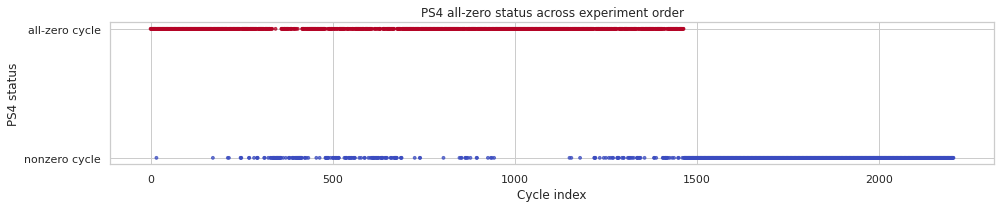

PS4 status × cooler


cooler,3,20,100
PS4_status,,,
all_zero,578,660,0
nonzero,154,72,741


PS4 status × valve


valve,73,80,90,100
PS4_status,,,,
all_zero,189,201,192,656
nonzero,171,159,168,469


PS4 status × pump_leakage


...

accumulator,90,100,115,130
PS4_status,,,,
all_zero,385,201,207,445
nonzero,423,198,192,154


PS4 status × stable


stable,0,1
PS4_status,,
all_zero,772,466
nonzero,677,290


Valve cross-tab is retained as a rejected hypothesis test: all four valve classes occur in both PS4 status groups, but valve is not the physically relevant target for PS4.


,cooler,PS4_status,n,mean_bar,median_bar
0,3,all_zero,578,0.000000,0.000000
1,3,nonzero,154,0.257952,0.020317
2,20,all_zero,660,0.000000,0.000000
3,20,nonzero,72,0.048858,0.008920
4,100,nonzero,741,7.679277,10.070701


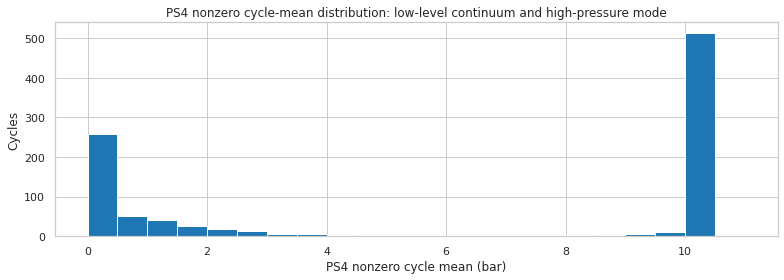

,lower_bar,upper_bar,cycles
0,0.0,0.5,259
1,0.5,1.0,52
2,1.0,2.0,67
3,2.0,3.0,32
4,3.0,4.0,10
5,4.0,5.0,4
6,5.0,6.0,2
7,6.0,7.0,1
8,7.0,8.0,4
9,8.0,9.0,6


,bin,cycles,zero_cycles,zero_fraction,cooler_values
0,"[0, 100)",100,99,0.99,3
1,"[100, 200)",100,99,0.99,3
2,"[200, 300)",100,89,0.89,3
3,"[300, 400)",100,59,0.59,3
4,"[400, 500)",100,71,0.71,3
5,"[500, 600)",100,69,0.69,3
6,"[600, 700)",100,61,0.61,3
7,"[700, 800)",100,97,0.97,"3,20"
8,"[800, 900)",100,89,0.89,20
9,"[900, 1000)",100,96,0.96,20


,unit,PS4_zero_mean,PS4_nonzero_mean,difference_nonzero_minus_zero
sensor,,,,
PS5,bar,8.820762,9.601880,0.781118
PS6,bar,8.752417,9.497934,0.745518
FS2,l/min,9.419834,9.943422,0.523588
CE,%,23.655502,41.084751,17.429249
CP,kW,1.633898,2.031803,0.397905
TS3,°C,51.685326,42.511425,-9.173901
TS4,°C,45.251759,34.953922,-10.297836
TS1,°C,49.777641,39.851555,-9.926086


In [3]:
arrays={}; load_stats=[]
for s in registry.index:
    arr=np.loadtxt(DATA/f'{s}.txt', delimiter='\t', dtype=np.float32)
    arrays[s]=arr
    all_zero=(arr==0).all(axis=1)
    flatlined=np.ptp(arr,axis=1)==0
    unique_total=np.unique(arr,axis=0).shape[0]
    nonzero_unique=np.unique(arr[~all_zero],axis=0).shape[0]
    load_stats.append({'sensor':s,'shape':arr.shape,'nan':int(np.isnan(arr).sum()),'inf':int(np.isinf(arr).sum()),'zeros':int((arr==0).sum()),'exact_zero_fraction':float((arr==0).mean()),'negative':int((arr<0).sum()),'constant_cols':int((np.nanmax(arr,axis=0)-np.nanmin(arr,axis=0)==0).sum()),'near_constant_cols_range<1e-6':int((np.nanmax(arr,axis=0)-np.nanmin(arr,axis=0)<1e-6).sum()),'all_zero_cycles':int(all_zero.sum()),'flatlined_cycles':int(flatlined.sum()),'unique_cycles':int(unique_total),'duplicate_rows':int(arr.shape[0]-unique_total),'nonzero_unique_cycles':int(nonzero_unique)})
INVALID=pd.DataFrame(load_stats).set_index('sensor'); display(INVALID)
print('Total NaN:',int(INVALID.nan.sum()),'Total inf:',int(INVALID.inf.sum()),'negative pressure/flow:',int(INVALID.loc[['PS1','PS2','PS3','PS4','PS5','PS6','FS1','FS2'],'negative'].sum()))
print('Sensors with all-zero cycles:',INVALID.index[INVALID.all_zero_cycles>0].tolist())
print('Sensors with within-cycle flatlined cycles:',INVALID.index[INVALID.flatlined_cycles>0].tolist())
audit_target_names=['cooler','valve','pump_leakage','accumulator','stable']
audit_targets=pd.read_csv(LABELS_DIR/'profile.txt',sep='\t',header=None,names=audit_target_names,dtype=np.int16)
ps4_zero=(arrays['PS4']==0).all(axis=1)
ps4_cycle_mean=arrays['PS4'].mean(axis=1)
print(f"PS4 all-zero cycles: {int(ps4_zero.sum())}/{N_CYCLES} ({ps4_zero.mean():.1%}); nonzero cycles: {int((~ps4_zero).sum())}; unique nonzero cycles: {int(np.unique(arrays['PS4'][~ps4_zero],axis=0).shape[0])}")
fig,ax=plt.subplots(figsize=(14,3)); ax.scatter(audit_targets.index,ps4_zero.astype(int),s=8,c=ps4_zero,cmap='coolwarm',alpha=.75); ax.set(yticks=[0,1],yticklabels=['nonzero cycle','all-zero cycle'],xlabel='Cycle index',ylabel='PS4 status',title='PS4 all-zero status across experiment order'); plt.tight_layout(); plt.show()
ps4_status=pd.Series(np.where(ps4_zero,'all_zero','nonzero'),index=audit_targets.index,name='PS4_status')
for target in audit_target_names:
    print(f'PS4 status × {target}'); display(pd.crosstab(ps4_status,audit_targets[target]))
print('Valve cross-tab is retained as a rejected hypothesis test: all four valve classes occur in both PS4 status groups, but valve is not the physically relevant target for PS4.')
conditioned=pd.DataFrame({'cooler':audit_targets.cooler,'PS4_status':ps4_status,'PS4_cycle_mean_bar':ps4_cycle_mean}).groupby(['cooler','PS4_status']).agg(n=('PS4_cycle_mean_bar','size'),mean_bar=('PS4_cycle_mean_bar','mean'),median_bar=('PS4_cycle_mean_bar','median')).reset_index()
display(conditioned)
nonzero_means=ps4_cycle_mean[~ps4_zero]
fig,ax=plt.subplots(figsize=(11,4)); ax.hist(nonzero_means,bins=np.arange(0,11.5,.5),color='tab:blue',edgecolor='white'); ax.set(xlabel='PS4 nonzero cycle mean (bar)',ylabel='Cycles',title='PS4 nonzero cycle-mean distribution: low-level continuum and high-pressure mode'); plt.tight_layout(); plt.show()
hist_edges=np.array([0,.5,1,2,3,4,5,6,7,8,9,10,11,np.inf]); hist_counts=pd.DataFrame({'lower_bar':hist_edges[:-1],'upper_bar':hist_edges[1:],'cycles':[int(((nonzero_means>=lo)&(nonzero_means<hi)).sum()) for lo,hi in zip(hist_edges[:-1],hist_edges[1:])]}); display(hist_counts)
coarse_edges=np.r_[np.arange(0,1501,100),N_CYCLES]; cycle_bins=pd.DataFrame({'cycle_index':audit_targets.index,'PS4_zero':ps4_zero,'cooler':audit_targets.cooler}).assign(bin=pd.cut(audit_targets.index,bins=coarse_edges,right=False,include_lowest=True))
zero_bin_table=cycle_bins.groupby('bin',observed=False).agg(cycles=('PS4_zero','size'),zero_cycles=('PS4_zero','sum'),zero_fraction=('PS4_zero','mean'),cooler_values=('cooler',lambda x: ','.join(map(str,sorted(x.unique()))))).reset_index(); display(zero_bin_table)
cooling_sensors=['PS5','PS6','FS2','CE','CP','TS3','TS4','TS1']; cooling_rows=[]
for s in cooling_sensors:
    vals=arrays[s].mean(axis=1); cooling_rows.append({'sensor':s,'unit':registry.loc[s,'unit'],'PS4_zero_mean':vals[ps4_zero].mean(),'PS4_nonzero_mean':vals[~ps4_zero].mean(),'difference_nonzero_minus_zero':vals[~ps4_zero].mean()-vals[ps4_zero].mean()})
cooling_table=pd.DataFrame(cooling_rows).set_index('sensor'); display(cooling_table)


## 4. Targets and experiment ordering

`profile.txt` is row-aligned with cycles and contains four component conditions plus a stable flag. We compare observed class counts with the documented class sets, inspect all target co-occurrences, and plot target labels against cycle index. Because the experiment is ordered by condition regimes and the stable flag marks static-settling periods, random row splits can leak neighboring/regime information; blocked or grouped validation should be considered later.

cooler observed= {3: 732, 20: 732, 100: 741} documented_classes= [3, 20, 100] unexpected= []
valve observed= {73: 360, 80: 360, 90: 360, 100: 1125} documented_classes= [73, 80, 90, 100] unexpected= []
pump_leakage observed= {0: 1221, 1: 492, 2: 492} documented_classes= [0, 1, 2] unexpected= []
accumulator observed= {90: 808, 100: 399, 115: 399, 130: 599} documented_classes= [90, 100, 115, 130] unexpected= []
stable observed= {0: 1449, 1: 756} documented_classes= [0, 1] unexpected= []


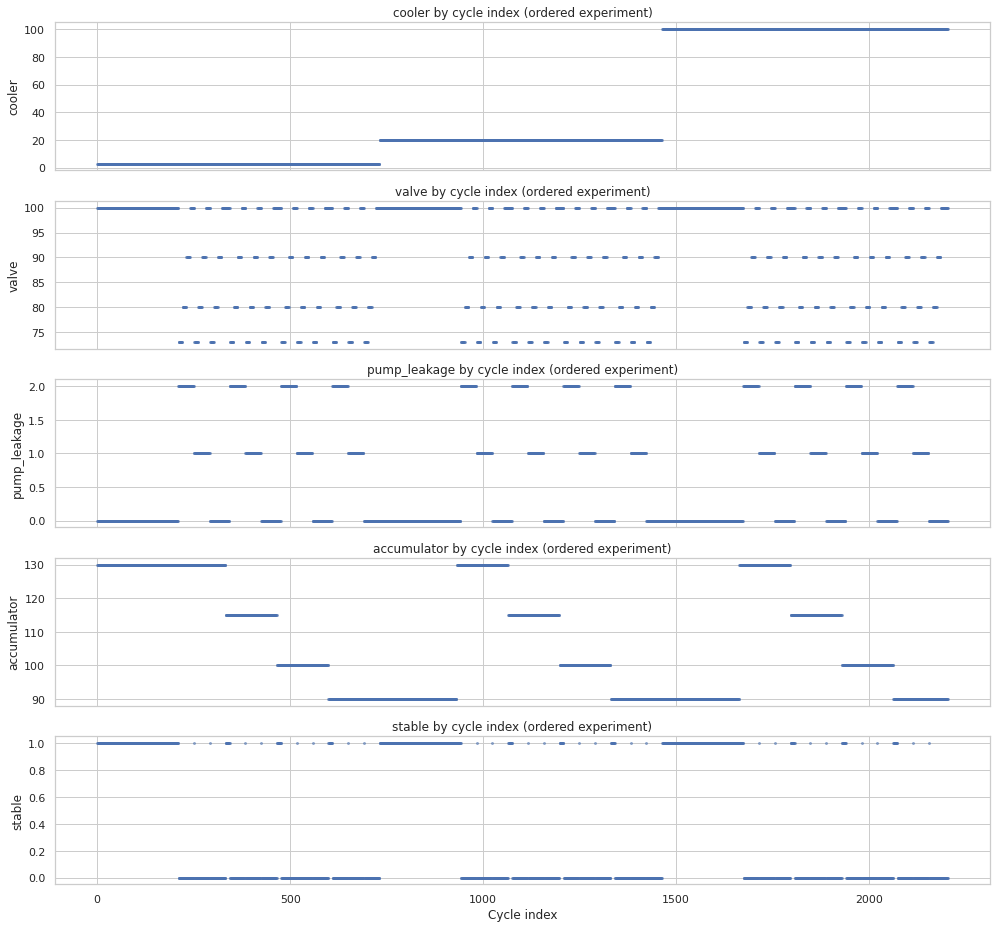

**cooler × stable**

stable,0,1
cooler,,
3,480,252
20,480,252
100,489,252


**valve × stable**

stable,0,1
valve,,
73,360,0
80,360,0
90,360,0
100,369,756


**pump_leakage × stable**

stable,0,1
pump_leakage,,
0,489,732
1,480,12
2,480,12


**accumulator × stable**

stable,0,1
accumulator,,
90,369,439
100,360,39
115,360,39
130,360,239


**Four-way target combination counts (rare combinations are visible here):**

,cooler,valve,pump_leakage,accumulator,cycles
132,100,100,0,90,230
39,3,100,0,130,221
84,20,100,0,90,221
36,3,100,0,90,21
133,100,100,0,100,21
38,3,100,0,115,21
85,20,100,0,100,21
87,20,100,0,130,21
37,3,100,0,100,21
135,100,100,0,130,21


In [4]:
target_names=['cooler','valve','pump_leakage','accumulator','stable']
targets=pd.read_csv(LABELS_DIR/'profile.txt',sep='\t',header=None,names=target_names,dtype=np.int16)
targets.index.name='cycle'; targets['cycle_index']=np.arange(len(targets))
documented={'cooler':[3,20,100],'valve':[73,80,90,100],'pump_leakage':[0,1,2],'accumulator':[90,100,115,130],'stable':[0,1]}
for c in target_names:
    print(c, 'observed=',targets[c].value_counts().sort_index().to_dict(), 'documented_classes=',documented[c], 'unexpected=',sorted(set(targets[c])-set(documented[c])))
fig,axs=plt.subplots(5,1,figsize=(14,13),sharex=True)
for ax,c in zip(axs,target_names): ax.scatter(targets.index,targets[c],s=4,alpha=.5); ax.set_ylabel(c); ax.set_title(f'{c} by cycle index (ordered experiment)')
axs[-1].set_xlabel('Cycle index'); plt.tight_layout(); plt.show()
for c in target_names[:-1]:
    display(Markdown(f'**{c} × stable**')); display(pd.crosstab(targets[c],targets.stable))
display(Markdown('**Four-way target combination counts (rare combinations are visible here):**')); display(targets.groupby(target_names[:4]).size().reset_index(name='cycles').sort_values('cycles',ascending=False).head(30))


## 5. Per-sensor cycle-level summary statistics

For every cycle and sensor we compute mean, standard deviation, minimum, maximum, median, IQR, skewness, and excess kurtosis. These statistics describe the 2,205 × 17 cycle-mean representation and richer cycle-level descriptors. Histograms/KDEs and boxplots reveal scale, skew, multimodality, and outliers before any normalization.

cycle means shape: (2205, 17)


,count,mean,std,min,25%,50%,75%,max
PS1,2205.0,160.485321,4.699424,155.391541,158.100204,158.960892,161.000732,180.922714
PS2,2205.0,109.379906,4.986585,104.406311,106.962387,107.730164,109.421608,131.589096
PS3,2205.0,1.753227,0.251902,0.840253,1.729733,1.779631,1.932047,2.023398
PS4,2205.0,2.600266,4.279355,0.000000,0.000000,0.000000,3.503266,10.207067
PS5,2205.0,9.163321,0.576296,8.365800,8.547239,9.115781,9.844351,9.978511
PS6,2205.0,9.079363,0.549589,8.321526,8.487166,9.031516,9.729276,9.856591
EPS1,2205.0,2495.509277,73.836685,2361.747314,2442.933350,2480.926758,2548.211670,2740.641113
FS1,2205.0,6.198550,1.032883,2.018572,6.391670,6.576673,6.657508,6.722706
FS2,2205.0,9.649452,0.449246,8.857513,9.203397,9.692270,10.155008,10.403099
TS1,2205.0,45.424568,7.991933,35.313786,36.237148,44.836655,54.104313,57.899284


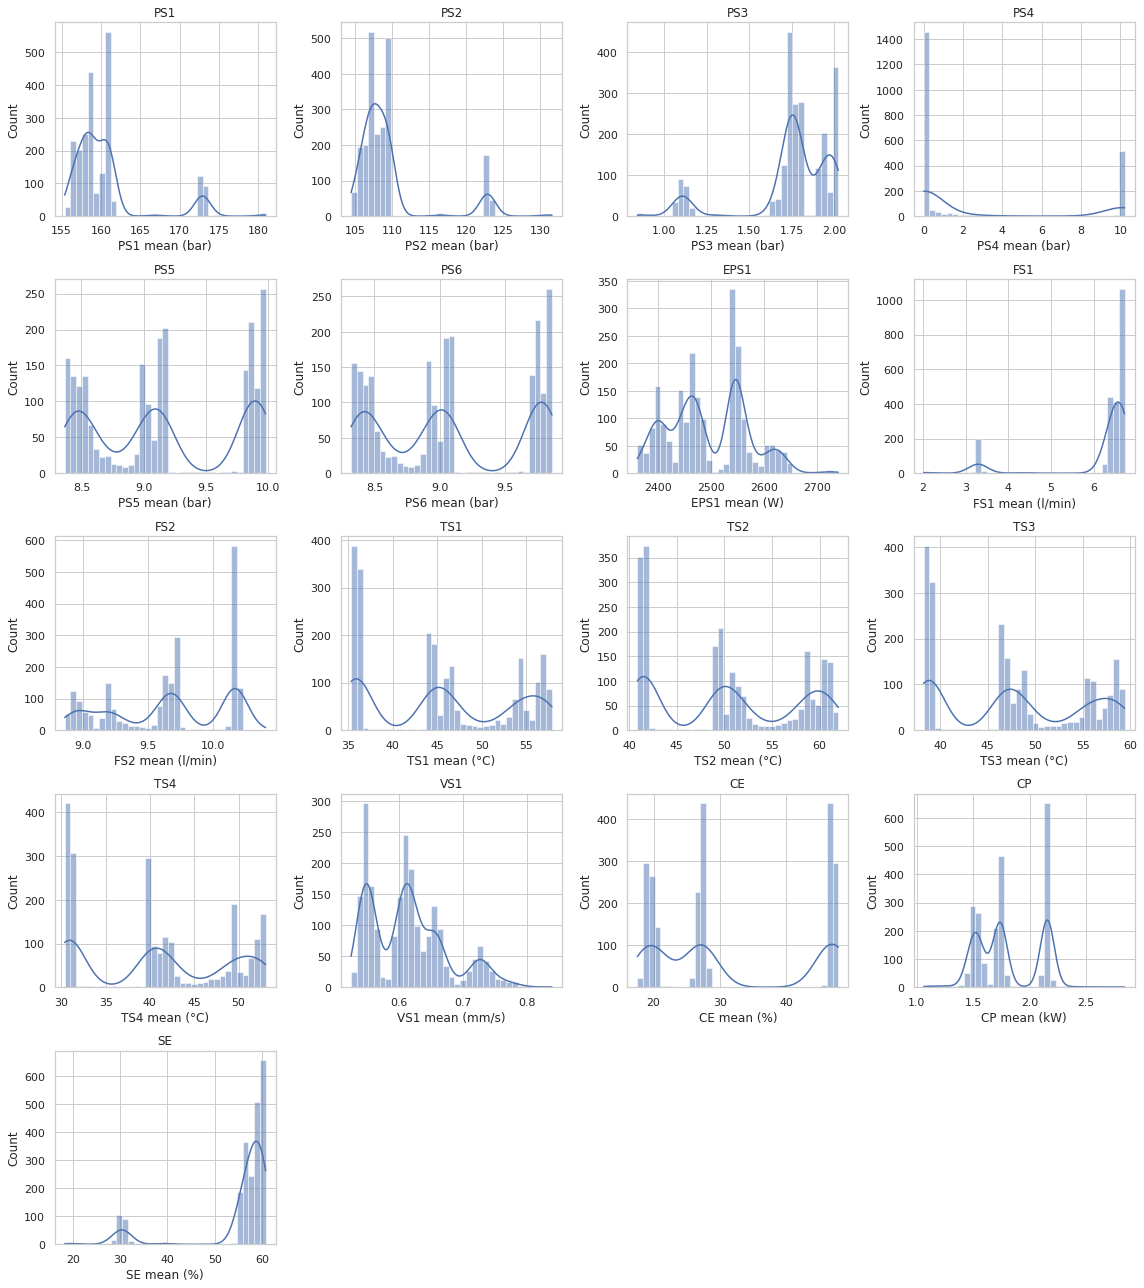

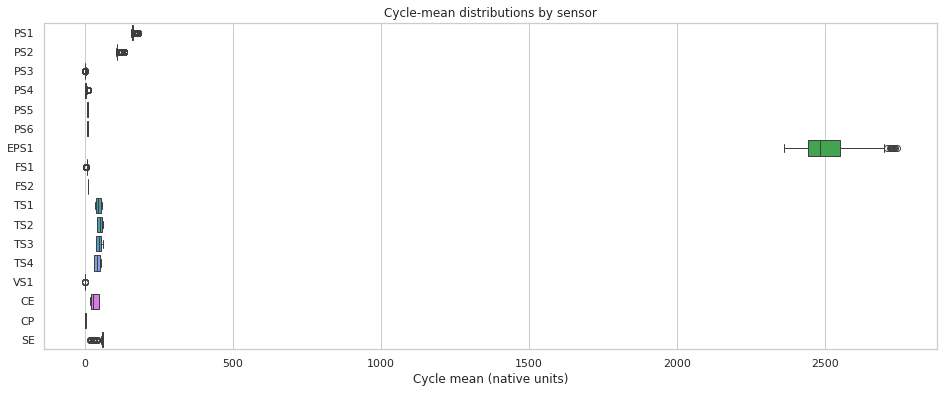

In [5]:
def cycle_stats(arr):
    q=np.nanpercentile(arr,[25,50,75],axis=1)
    return pd.DataFrame({'mean':np.nanmean(arr,1),'std':np.nanstd(arr,1),'min':np.nanmin(arr,1),'max':np.nanmax(arr,1),'median':q[1],'iqr':q[2]-q[0],'skew':stats.skew(arr,axis=1,bias=False,nan_policy='omit'),'kurtosis':stats.kurtosis(arr,axis=1,bias=False,nan_policy='omit')})
cycle_stats_by_sensor={s:cycle_stats(a) for s,a in arrays.items()}
cycle_means=pd.DataFrame({s:v['mean'] for s,v in cycle_stats_by_sensor.items()}); cycle_means.index.name='cycle'
print('cycle means shape:',cycle_means.shape); display(cycle_means.describe().T)
fig,axs=plt.subplots(5,4,figsize=(16,18)); axs=axs.ravel()
for ax,s in zip(axs,registry.index): sns.histplot(cycle_means[s],kde=True,ax=ax,bins=35); ax.set_title(s); ax.set_xlabel(f'{s} mean ({registry.loc[s,"unit"]})')
for ax in axs[len(registry):]: ax.axis('off')
plt.tight_layout(); plt.show()
plt.figure(figsize=(16,6)); sns.boxplot(data=cycle_means,orient='h'); plt.title('Cycle-mean distributions by sensor'); plt.xlabel('Cycle mean (native units)'); plt.show()


## 6. Within-cycle temporal structure

The signals have different time bases: 100 Hz channels have 6,000 samples, 10 Hz have 600, and 1 Hz have 60. We overlay a deterministic sample of raw cycles, then show the all-cycle mean ± standard deviation envelope. Class-conditioned waveforms focus on the documented component/sensor relationships and make clear which effects are transient versus cycle-wide. Only the overlaid raw traces are subsampled for legibility; envelopes and class means use all cycles.

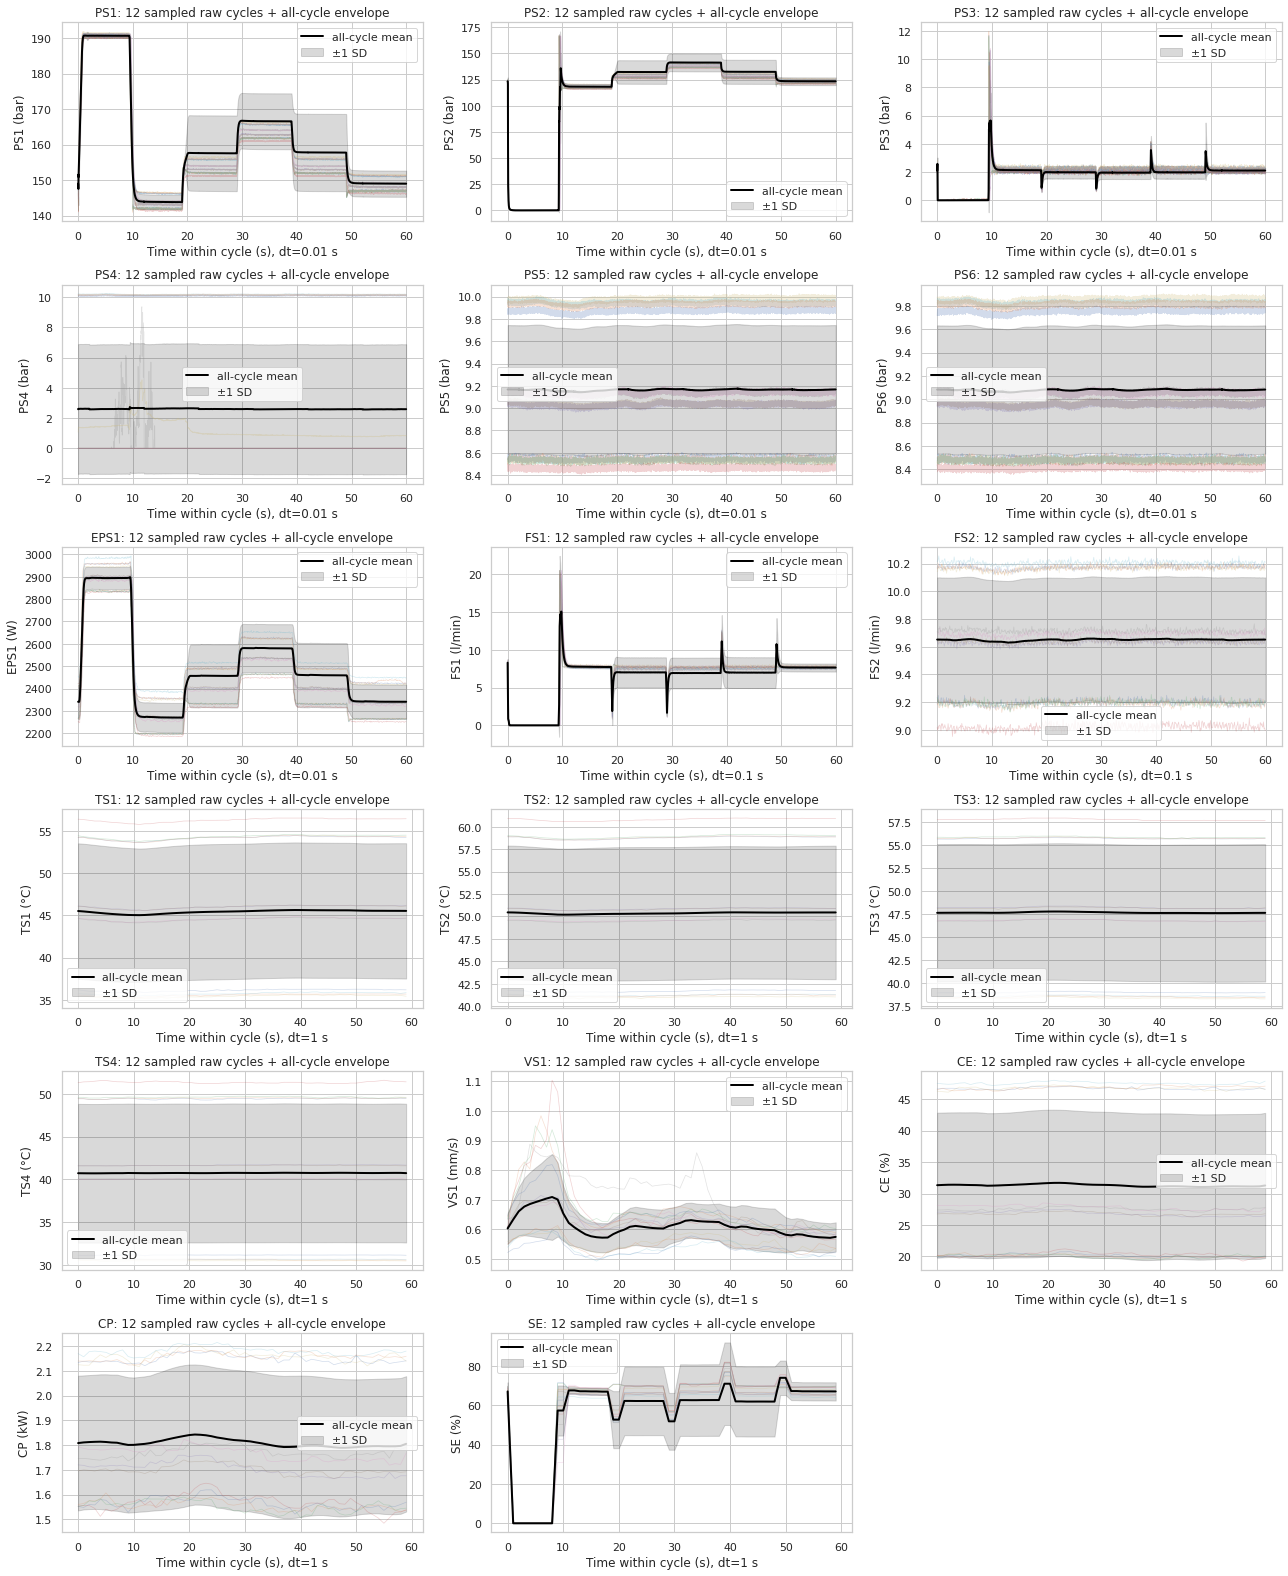

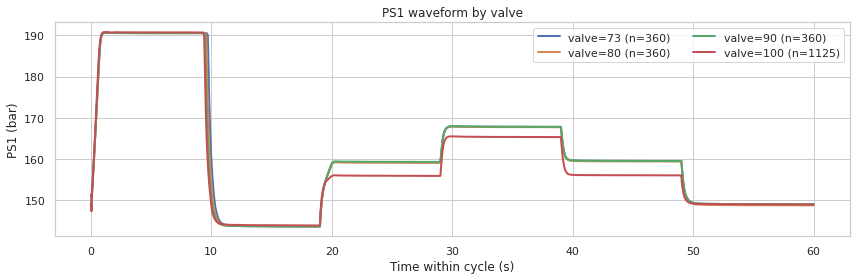

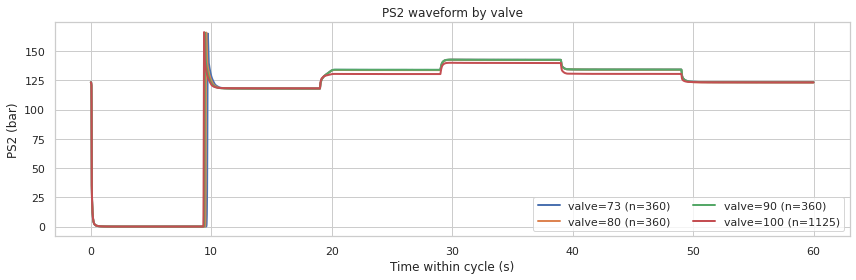

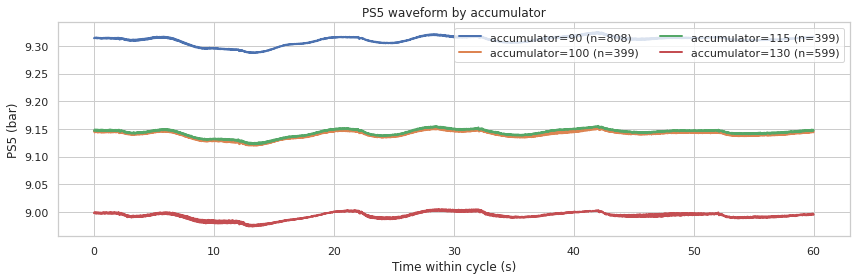

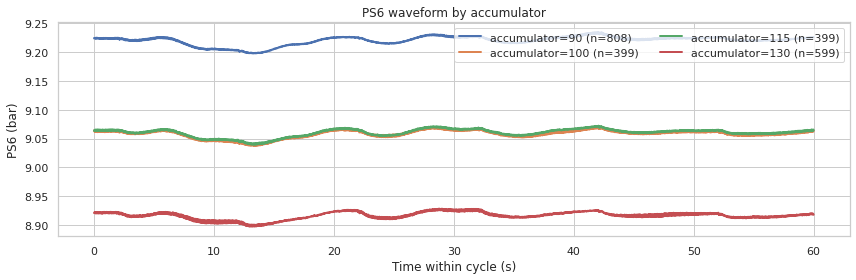

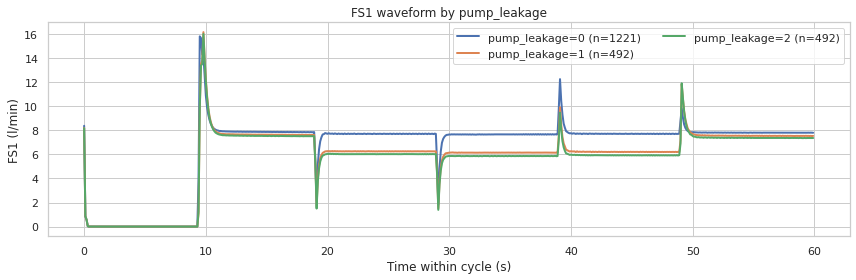

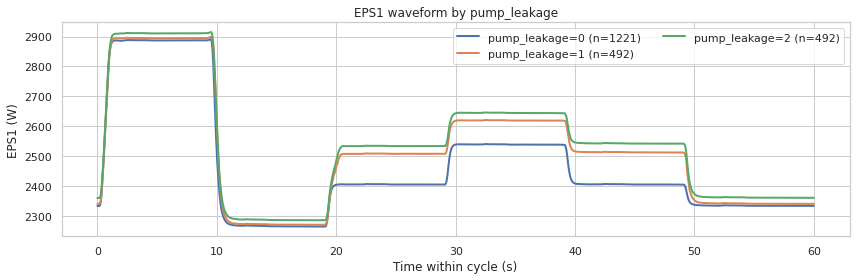

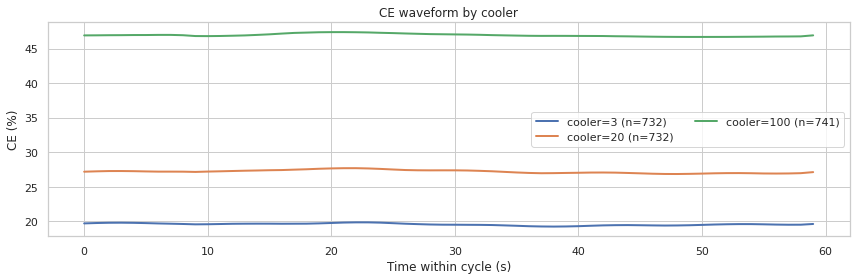

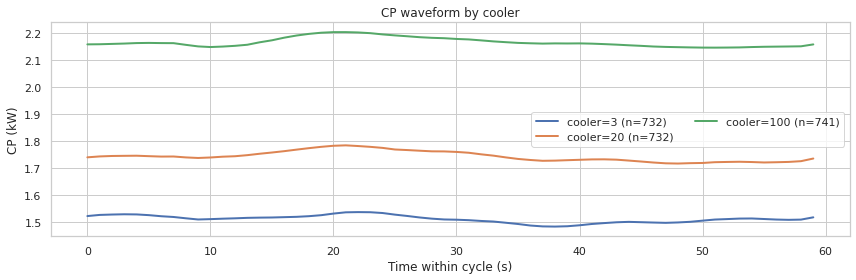

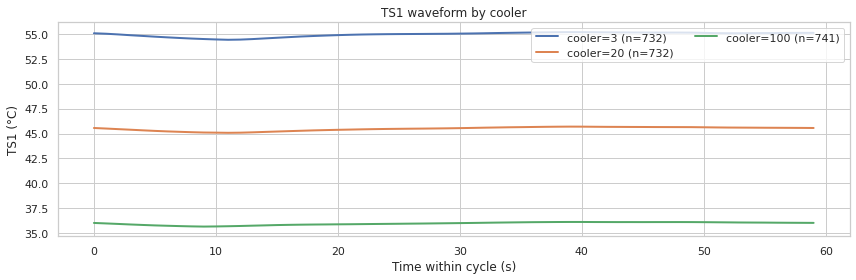

In [6]:
def time_axis(s): return np.arange(registry.loc[s,'n_cols'])/registry.loc[s,'hz']
def plot_wave(s, cycles, title, ax=None):
    if ax is None: _,ax=plt.subplots(figsize=(12,4))
    t=time_axis(s); a=arrays[s]
    for i in cycles: ax.plot(t,a[i],alpha=.25,lw=.7)
    m=a.mean(0); sd=a.std(0); ax.plot(t,m,color='black',lw=2,label='all-cycle mean'); ax.fill_between(t,m-sd,m+sd,color='black',alpha=.15,label='±1 SD')
    ax.set(xlabel=f'Time within cycle (s), dt={1/registry.loc[s,"hz"]:.3g} s',ylabel=f'{s} ({registry.loc[s,"unit"]})',title=title); ax.legend(); return ax
rng=np.random.default_rng(SEED); sample_cycles=np.sort(rng.choice(N_CYCLES, size=12, replace=False))
fig,axs=plt.subplots(6,3,figsize=(18,22));
for ax,s in zip(axs.ravel(),registry.index): plot_wave(s,sample_cycles,f'{s}: 12 sampled raw cycles + all-cycle envelope',ax)
for ax in axs.ravel()[len(registry):]: ax.axis('off')
plt.tight_layout(); plt.show()
class_views=[('valve','PS1'),('valve','PS2'),('accumulator','PS5'),('accumulator','PS6'),('pump_leakage','FS1'),('pump_leakage','EPS1'),('cooler','CE'),('cooler','CP'),('cooler','TS1')]
for target,s in class_views:
    fig,ax=plt.subplots(figsize=(12,4)); t=time_axis(s)
    for val,g in targets.groupby(target):
        idx=g.index.to_numpy(); ax.plot(t,arrays[s][idx].mean(0),lw=2,label=f'{target}={val} (n={len(idx)})')
    ax.set(xlabel='Time within cycle (s)',ylabel=f'{s} ({registry.loc[s,"unit"]})',title=f'{s} waveform by {target}'); ax.legend(ncol=2); plt.tight_layout(); plt.show()


## 7. Long-term and cross-cycle drift

Cycle means are plotted against the original cycle index with rolling location/scale and stable-flag overlay. Regime changes and warm-up are expected in an experiment-ordered dataset; the papers also motivate attention to sensor drift/fault behavior. Drift means that random splits can be optimistic and that temporal normalization must not use future information.

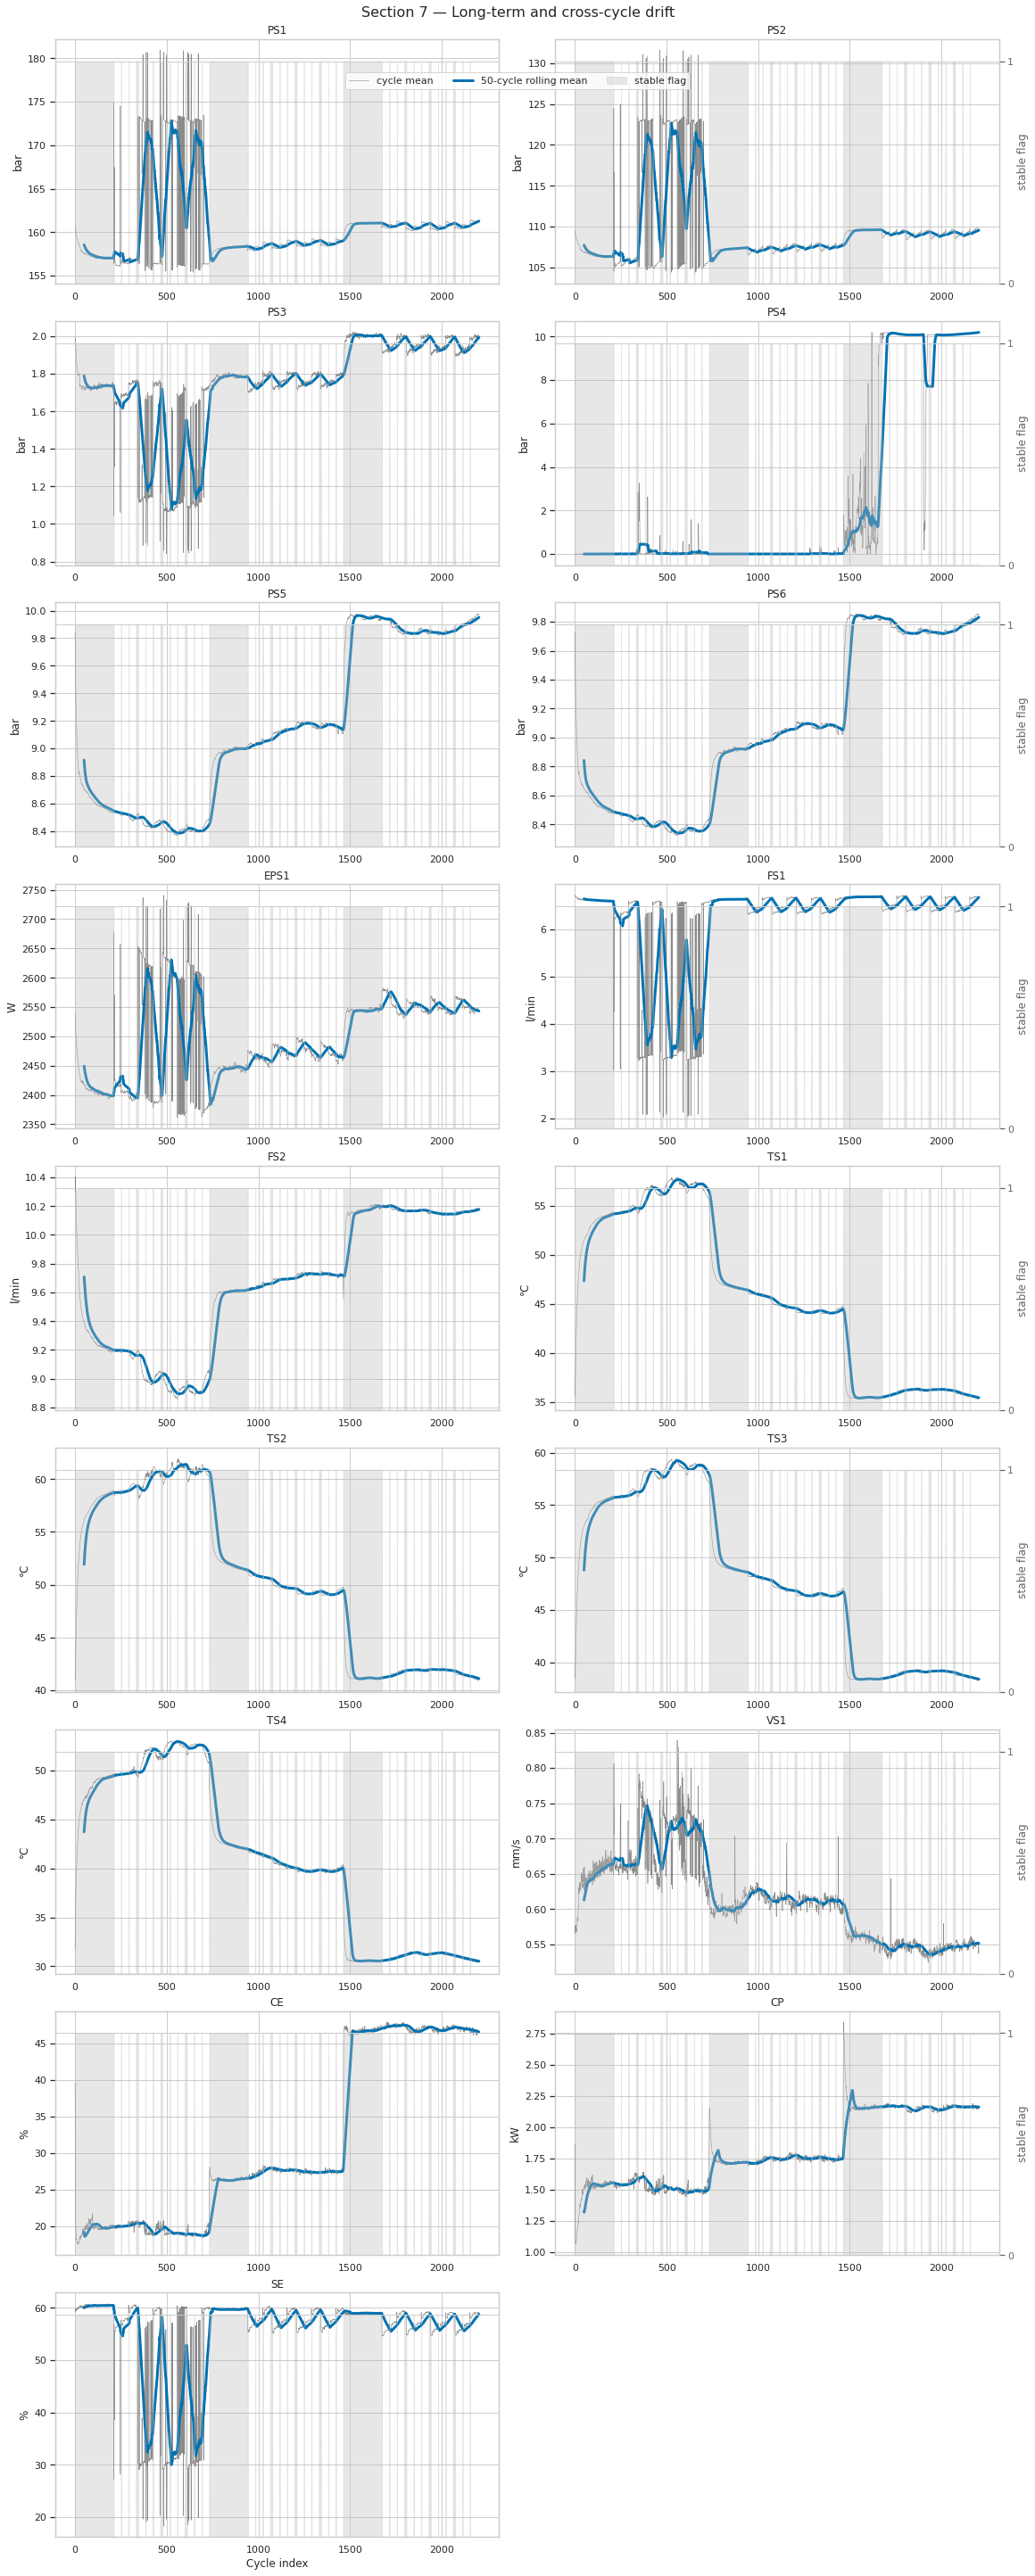

In [7]:
roll=50
raw_color='#4D4D4D'; trend_color='#0072B2'; stable_color='#BDBDBD'; stable_text_color='#666666'
fig,axs=plt.subplots(9,2,figsize=(16,40),constrained_layout=True); axs=axs.ravel()
legend_handles=None
for panel_idx,(ax,s) in enumerate(zip(axs,registry.index)):
    row,col=divmod(panel_idx,2)
    x=cycle_means[s]
    raw_line,=ax.plot(x.index,x,color=raw_color,alpha=.65,lw=.6,label='cycle mean')
    rolling_line,=ax.plot(x.rolling(roll).mean(),color=trend_color,lw=3,label=f'{roll}-cycle rolling mean',zorder=4)
    ax2=ax.twinx()
    stable_patch=ax2.fill_between(targets.index,0,targets.stable,color=stable_color,alpha=.35,label='stable flag',zorder=0)
    ax2.set_ylim(0,1.1); ax2.set_yticks([0,1])
    if col==1:
        ax2.set_ylabel('stable flag',color=stable_text_color)
        ax2.tick_params(axis='y',colors=stable_text_color,labelright=True)
    else:
        ax2.set_ylabel('')
        ax2.tick_params(axis='y',right=False,labelright=False,length=0)
    ax.set_title(s)
    ax.set_ylabel(registry.loc[s,'unit'])
    if row==8: ax.set_xlabel('Cycle index')
    else: ax.set_xlabel('')
    if legend_handles is None: legend_handles=[raw_line,rolling_line,stable_patch]
for ax in axs[len(registry):]: ax.axis('off')
fig.suptitle('Section 7 — Long-term and cross-cycle drift',fontsize=16)
fig.legend(legend_handles,['cycle mean',f'{roll}-cycle rolling mean','stable flag'],loc='upper center',bbox_to_anchor=(0.5,0.975),ncol=3)
plt.show()


## 8. Relationships, redundancy, and target signal

Pearson captures linear relationships while Spearman captures monotonic relationships robustly to scale and outliers. We cluster sensor means to identify redundancy. Mutual information and ANOVA F/eta-squared provide screening evidence—not a leakage-safe predictive evaluation—about which cycle-level sensors carry signal for each component. PCA plots show separability in standardized cycle means; t-SNE is omitted to keep execution deterministic and compact.

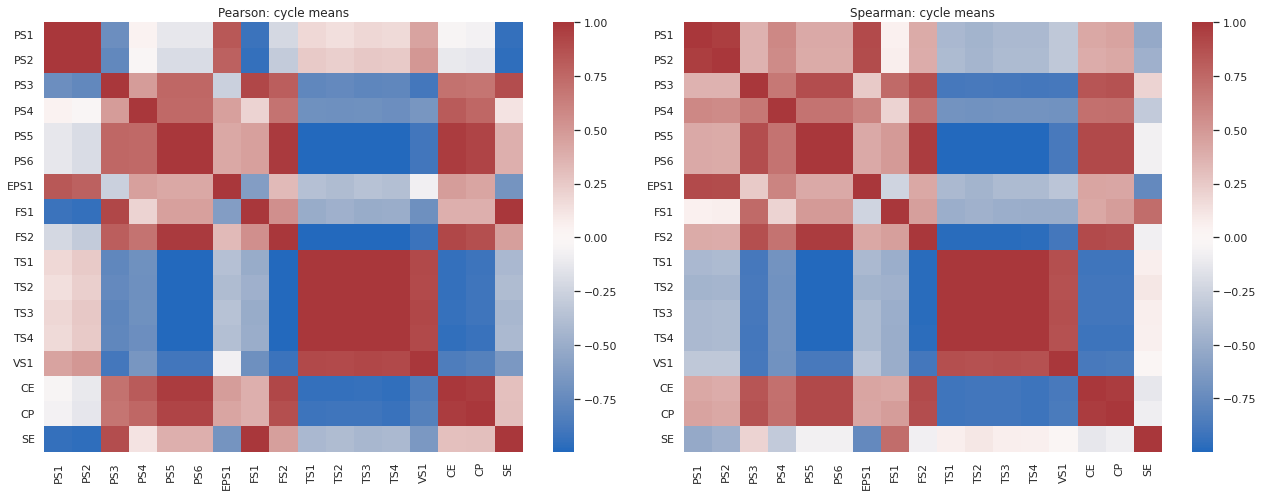

Top absolute Pearson pairs


r
PS5 PS6  0.999993
TS1 TS3  0.999732
    TS2  0.999344
    TS4  0.999242
TS2 TS3  0.999067
TS3 TS4  0.998395
TS2 TS4  0.998292
FS2 TS3 -0.996281
PS1 PS2  0.995294
PS5 TS4 -0.995100
PS6 TS4 -0.994925
FS2 TS1 -0.994654
FS1 SE   0.994564
FS2 TS2 -0.993142
PS5 TS2 -0.992940

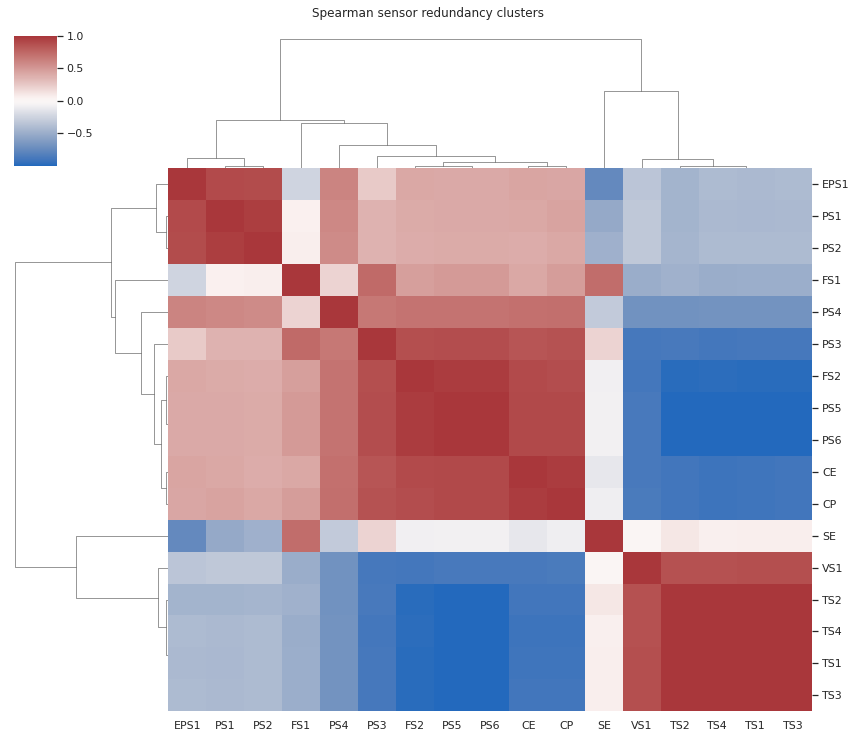

Top sensors for cooler


,mutual_information,anova_f,eta_squared
CE,1.088549,248707.501668,0.995593
CP,1.083736,20375.254491,0.948734
TS4,1.037901,23686.231593,0.955582
PS5,1.032893,28825.569846,0.963210
PS6,1.032207,29143.214706,0.963596
TS1,1.017553,18864.658417,0.944856
TS2,1.005907,18034.366278,0.942462
TS3,1.003467,16017.048892,0.935682


Top sensors for valve


,mutual_information,anova_f,eta_squared
PS2,0.591092,12.128563,0.016263
PS1,0.580237,21.196627,0.028080
TS3,0.439167,0.603642,0.000822
TS1,0.436916,0.561868,0.000765
SE,0.415673,47.453998,0.060751
TS2,0.405668,0.278328,0.000379
TS4,0.376970,0.493220,0.000672
FS1,0.371404,33.540962,0.043718


Top sensors for pump_leakage


,mutual_information,anova_f,eta_squared
SE,0.848033,342.100588,0.237060
FS1,0.845199,264.078828,0.193453
EPS1,0.630895,255.787058,0.188524
PS1,0.578365,136.464932,0.110279
PS3,0.570923,173.697775,0.136266
TS4,0.489642,0.811030,0.000736
TS1,0.475474,0.769698,0.000699
TS3,0.472601,0.892663,0.000810


Top sensors for accumulator


,mutual_information,anova_f,eta_squared
TS1,0.841179,32.409169,0.042305
TS4,0.834577,32.971641,0.043008
TS3,0.824437,29.466287,0.038612
TS2,0.815019,33.049401,0.043105
PS5,0.779076,37.135889,0.048178
PS6,0.762048,37.450673,0.048567
FS2,0.739306,19.399805,0.025761
EPS1,0.549473,96.594721,0.116343


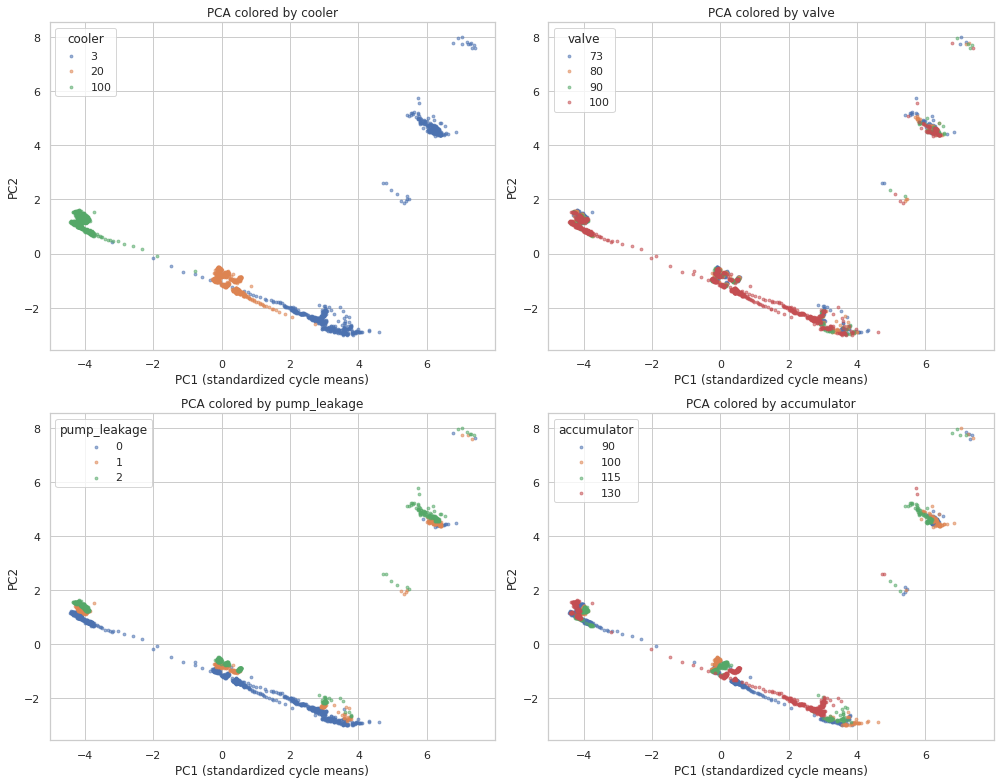

In [8]:
pearson=cycle_means.corr('pearson'); spearman=cycle_means.corr('spearman')
fig,axs=plt.subplots(1,2,figsize=(18,7)); sns.heatmap(pearson,ax=axs[0],cmap='vlag',center=0); axs[0].set_title('Pearson: cycle means'); sns.heatmap(spearman,ax=axs[1],cmap='vlag',center=0); axs[1].set_title('Spearman: cycle means'); plt.tight_layout(); plt.show()
links=pearson.where(np.triu(np.ones_like(pearson,dtype=bool),1)).stack().sort_values(key=np.abs,ascending=False); print('Top absolute Pearson pairs'); display(links.head(15).rename('r').to_frame())
sns.clustermap(spearman,cmap='vlag',center=0,figsize=(12,10),method='average'); plt.suptitle('Spearman sensor redundancy clusters',y=1.02); plt.show()
X=StandardScaler().fit_transform(cycle_means); informative={}
for target in target_names[:4]:
    y=targets[target].to_numpy(); mi=mutual_info_classif(X,y,random_state=SEED); f,p=f_classif(X,y); eta=[]
    grand=cycle_means.mean()
    for s in cycle_means.columns:
        groups=[cycle_means.loc[y==v,s] for v in np.unique(y)]; ssb=sum(len(g)*(g.mean()-cycle_means[s].mean())**2 for g in groups); sst=((cycle_means[s]-cycle_means[s].mean())**2).sum(); eta.append(ssb/sst if sst else 0)
    informative[target]=pd.DataFrame({'mutual_information':mi,'anova_f':f,'eta_squared':eta},index=cycle_means.columns).sort_values('mutual_information',ascending=False)
    print('Top sensors for',target); display(informative[target].head(8))
pca=PCA(n_components=2,random_state=SEED).fit_transform(X)
fig,axs=plt.subplots(2,2,figsize=(14,11))
for ax,target in zip(axs.ravel(),target_names[:4]):
    for val in sorted(targets[target].unique()):
        m=targets[target].to_numpy()==val; ax.scatter(pca[m,0],pca[m,1],s=8,alpha=.55,label=str(val))
    ax.set(xlabel='PC1 (standardized cycle means)',ylabel='PC2',title=f'PCA colored by {target}'); ax.legend(title=target)
plt.tight_layout(); plt.show()


## 9. Autocorrelation and spectral view (100 Hz channels)

Autocorrelation and Welch power spectral density are computed for representative 100 Hz cycles. The ACF is plotted as `ac[lag]` against lag time, so lag zero must equal 1.0 and subsequent values reveal decay/repetition. Peaks show repeating within-cycle structure; the high-frequency tail estimates the noise floor. These views inform whether later preparation should downsample, smooth, or retain transients. Both the PSD sampling frequency and ACF lag axis use the registry sampling rate rather than a hard-coded value.

PS1 ACF[0]=1.000000, ACF[1]=0.999858
PS2 ACF[0]=1.000000, ACF[1]=0.999679
PS5 ACF[0]=1.000000, ACF[1]=0.792110
EPS1 ACF[0]=1.000000, ACF[1]=0.999842


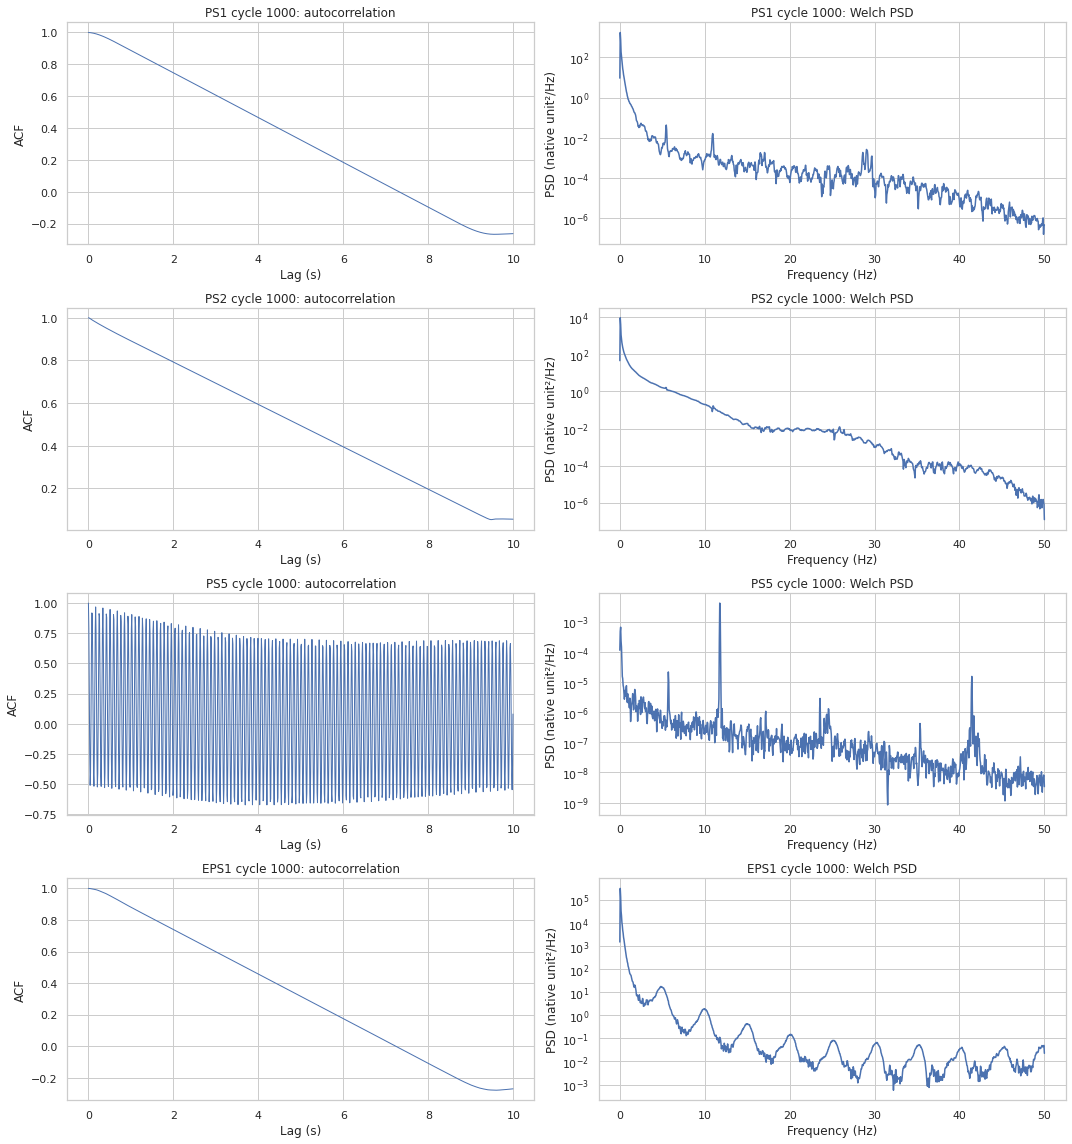

In [9]:
spec_sensors=['PS1','PS2','PS5','EPS1']; spec_cycle=1000
fig,axs=plt.subplots(len(spec_sensors),2,figsize=(15,16))
for r,s in enumerate(spec_sensors):
    x=arrays[s][spec_cycle].astype(float); x=x-x.mean(); ac=signal.fftconvolve(x,x[::-1],mode='full')[len(x)-1:]; ac/=ac[0]; lags=np.arange(min(1000,len(ac))); fs=registry.loc[s,'hz']; axs[r,0].plot(lags/fs,ac[:len(lags)],'-',lw=1); print(f'{s} ACF[0]={ac[0]:.6f}, ACF[1]={ac[1]:.6f}'); axs[r,0].set(xlabel='Lag (s)',ylabel='ACF',title=f'{s} cycle {spec_cycle}: autocorrelation')
    f,p=signal.welch(x,fs=fs,nperseg=2048); axs[r,1].semilogy(f,p+1e-16); axs[r,1].set(xlabel='Frequency (Hz)',ylabel='PSD (native unit²/Hz)',title=f'{s} cycle {spec_cycle}: Welch PSD')
plt.tight_layout(); plt.show()


## 10. Cycle-level outlier and anomaly scan

We use three complementary flags: robust IQR fences, absolute z-scores, and an Isolation Forest on standardized 17-sensor cycle means. These are screening flags, not automatic deletions: a rare cycle may be a valid severe condition or a sensor fault. The report lists suspicious cycle indices per sensor and the multivariate anomaly set.

In [10]:
outlier_rows=[]
for s in cycle_means:
    x=cycle_means[s]; q1,q3=x.quantile([.25,.75]); iqr=q3-q1; iqrflag=(x<q1-1.5*iqr)|(x>q3+1.5*iqr); zflag=np.abs(stats.zscore(x,nan_policy='omit'))>3
    outlier_rows.append({'sensor':s,'iqr_count':int(iqrflag.sum()),'z_gt_3_count':int(zflag.sum()),'iqr_cycles':list(x.index[iqrflag][:25]),'z_cycles':list(x.index[zflag][:25])})
OUTLIERS=pd.DataFrame(outlier_rows).set_index('sensor'); display(OUTLIERS)
iso=IsolationForest(n_estimators=200,contamination='auto',random_state=SEED,n_jobs=-1).fit_predict(X); mult_cycles=np.flatnonzero(iso==-1); print('Isolation Forest multivariate flagged cycles:',len(mult_cycles),mult_cycles[:100].tolist())


,iqr_count,z_gt_3_count,iqr_cycles,z_cycles
sensor,,,,
PS1,240,12,"[211, 214, 215, 247, 343, 345, 346, 347, 348, ...","[211, 370, 388, 395, 463, 483, 499, 591, 616, ..."
PS2,240,13,"[211, 214, 215, 247, 343, 345, 346, 347, 348, ...","[211, 247, 370, 388, 395, 463, 483, 499, 591, ..."
PS3,240,11,"[211, 214, 215, 247, 343, 345, 346, 347, 348, ...","[370, 388, 395, 463, 483, 499, 591, 616, 621, ..."
PS4,532,0,"[1619, 1620, 1656, 1658, 1659, 1660, 1661, 166...",[]
PS5,0,0,[],[]
PS6,0,0,[],[]
EPS1,10,8,"[370, 388, 395, 463, 483, 499, 616, 621, 633, ...","[370, 388, 395, 483, 499, 616, 621, 633]"
FS1,240,13,"[211, 214, 215, 247, 343, 345, 346, 347, 348, ...","[211, 247, 370, 388, 395, 463, 483, 499, 591, ..."
FS2,0,0,[],[]


Isolation Forest multivariate flagged cycles: 499 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 41, 211, 212, 213, 214, 215, 216, 219, 247, 248, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392]


## 11. Findings & implications for raw-signal preparation

The following points are concrete decisions for later raw-signal preparation and leakage-safe predictive evaluation. They are generated from the verified raw data above, not assumptions from the documentation.

In [11]:
# Compact numeric findings for the final report
print('Verified raw shapes:'); print({s:tuple(a.shape) for s,a in arrays.items()})
print('Total missing/NaN:',int(sum(np.isnan(a).sum() for a in arrays.values())),'total inf:',int(sum(np.isinf(a).sum() for a in arrays.values())))
print('Target counts:'); display(targets[target_names].apply(lambda x:x.value_counts().sort_index()))
print('Top Pearson pairs:'); display(links.head(10).rename('r').to_frame())
for t,df in informative.items(): print(t, 'top MI sensors:',df.head(5).index.tolist())
print('PS4 regime summary:', {'all_zero_cycles':int(ps4_zero.sum()),'all_zero_fraction_cycles':float(ps4_zero.mean()),'all_zero_sample_fraction':float((arrays['PS4']==0).mean()),'nonzero_cycles':int((~ps4_zero).sum()),'unique_nonzero_cycles':int(np.unique(arrays['PS4'][~ps4_zero],axis=0).shape[0]),'flatlined_cycles':int(INVALID.loc['PS4','flatlined_cycles'])})
print('Multivariate outlier cycles (first 50):',mult_cycles[:50].tolist())


Verified raw shapes:
{'PS1': (2205, 6000), 'PS2': (2205, 6000), 'PS3': (2205, 6000), 'PS4': (2205, 6000), 'PS5': (2205, 6000), 'PS6': (2205, 6000), 'EPS1': (2205, 6000), 'FS1': (2205, 600), 'FS2': (2205, 600), 'TS1': (2205, 60), 'TS2': (2205, 60), 'TS3': (2205, 60), 'TS4': (2205, 60), 'VS1': (2205, 60), 'CE': (2205, 60), 'CP': (2205, 60), 'SE': (2205, 60)}
Total missing/NaN: 0 total inf: 0
Target counts:


,cooler,valve,pump_leakage,accumulator,stable
0,NaN,NaN,1221.0,NaN,1449.0
1,NaN,NaN,492.0,NaN,756.0
2,NaN,NaN,492.0,NaN,NaN
3,732.0,NaN,NaN,NaN,NaN
20,732.0,NaN,NaN,NaN,NaN
73,NaN,360.0,NaN,NaN,NaN
80,NaN,360.0,NaN,NaN,NaN
90,NaN,360.0,NaN,808.0,NaN
100,741.0,1125.0,NaN,399.0,NaN
115,NaN,NaN,NaN,399.0,NaN


Top Pearson pairs:


r
PS5 PS6  0.999993
TS1 TS3  0.999732
    TS2  0.999344
    TS4  0.999242
TS2 TS3  0.999067
TS3 TS4  0.998395
TS2 TS4  0.998292
FS2 TS3 -0.996281
PS1 PS2  0.995294
PS5 TS4 -0.995100

cooler top MI sensors: ['CE', 'CP', 'TS4', 'PS5', 'PS6']
valve top MI sensors: ['PS2', 'PS1', 'TS3', 'TS1', 'SE']
pump_leakage top MI sensors: ['SE', 'FS1', 'EPS1', 'PS1', 'PS3']
accumulator top MI sensors: ['TS1', 'TS4', 'TS3', 'TS2', 'PS5']


PS4 regime summary: {'all_zero_cycles': 1238, 'all_zero_fraction_cycles': 0.5614512471655329, 'all_zero_sample_fraction': 0.6667763416477702, 'nonzero_cycles': 967, 'unique_nonzero_cycles': 967, 'flatlined_cycles': 1238}
Multivariate outlier cycles (first 50): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 41, 211, 212, 213, 214, 215, 216, 219, 247, 248]


### Actionable implications
1. **PS4 is informative process state, not a failed channel:** PS4 is exactly zero for **1,238/2,205 cycles (56.15% of cycles)** and **66.7% of all PS4 samples**; the remaining 967 nonzero cycles are all unique. Cooler-conditioned levels and corroborating cooling-circuit signals support genuine near-zero pressure in a depressurised/isolated cooling branch. **Do not drop PS4 and do not recode its zeros as missing.**
2. **PS4 shortcut risk:** PS4-zero is an almost perfect discriminator of cooler=100 versus degraded cooler phases, and cooler=100 is one contiguous experimental phase. Evaluate cooler prediction both with and without PS4 because a model can exploit experiment phase rather than learn a configuration-robust cooling relationship.
3. **PS4 raw-statistic conditioning:** for the 1,238 identically-zero cycles, PS4 variance is zero and higher-moment statistics are degenerate or ill-conditioned; retain the informative PS4 level/mean while handling within-cycle dispersion summaries carefully.
4. **Sampling-rate alignment:** retain native time axes (100 Hz/6,000; 10 Hz/600; 1 Hz/60), then choose an explicit resampling/window strategy rather than concatenating samples blindly.
5. **Cycle ordering and leakage:** labels occur in ordered experimental regimes and stable periods; use blocked/grouped or forward-chaining validation, and do not randomly split adjacent cycles without a leakage analysis.
6. **Class imbalance:** inspect the target counts and joint combinations above; use stratification where valid, class weights, and report per-class metrics.
7. **Scaling:** native units span bar, W, flow, °C, vibration, and percentages; standardize summaries using training folds only.
8. **Redundancy:** use the Pearson/Spearman clustermap and top pairs to reduce collinearity or regularize; do not discard sensors solely from correlation because component-specific transients can still matter.
9. **Drift and warm-up:** stable-flag overlays and rolling plots show why temporal drift, sensor drift, and regime boundaries should be modeled or excluded from preparation windows deliberately.
10. **Target-specific signal:** MI/ANOVA rankings are screening evidence for sensor-specific raw summaries; preserve waveform descriptors where class-conditioned plots show transient differences.
11. **Data volume:** cache raw arrays as float32 and calculate cycle-level tables once; reserve subsampling for plots only. The audit and all cycle summaries cover all 2,205 cycles.
12. **Outliers:** investigate listed cycles against stable flag and raw waveforms; flag or winsorize only with a physical explanation, never delete automatically.